In [104]:
import sys
from pathlib import Path
import importlib
import pandas as pd
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))
from Utility import IdSep
from Utility import Plot
import matplotlib.pyplot as plt

In [105]:
data_path = ROOT / "data" / "EOLENS_2_6.csv"
df = pd.read_csv(data_path)

# Plot composante classique

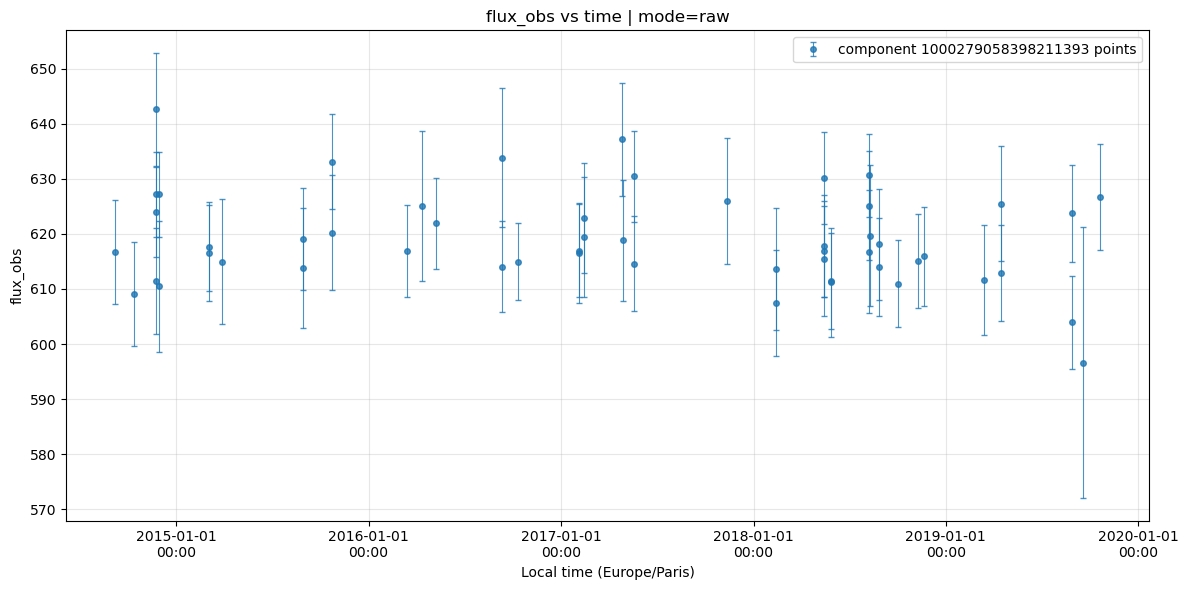

In [106]:
components = Plot.list_lens_components(data_path)
components[:10]
fig, ax = Plot.plot_lens_components_matplotlib(
    data_path,
    lens_component_ids=components[0],
    y_col="flux_obs",
    yerr_col="flux_obs_error",
    y_mode="raw",
    show_points=True,
    show_smooth=False,
    show_gp=False,
)

plt.show()

# Plot composante + Time Delay

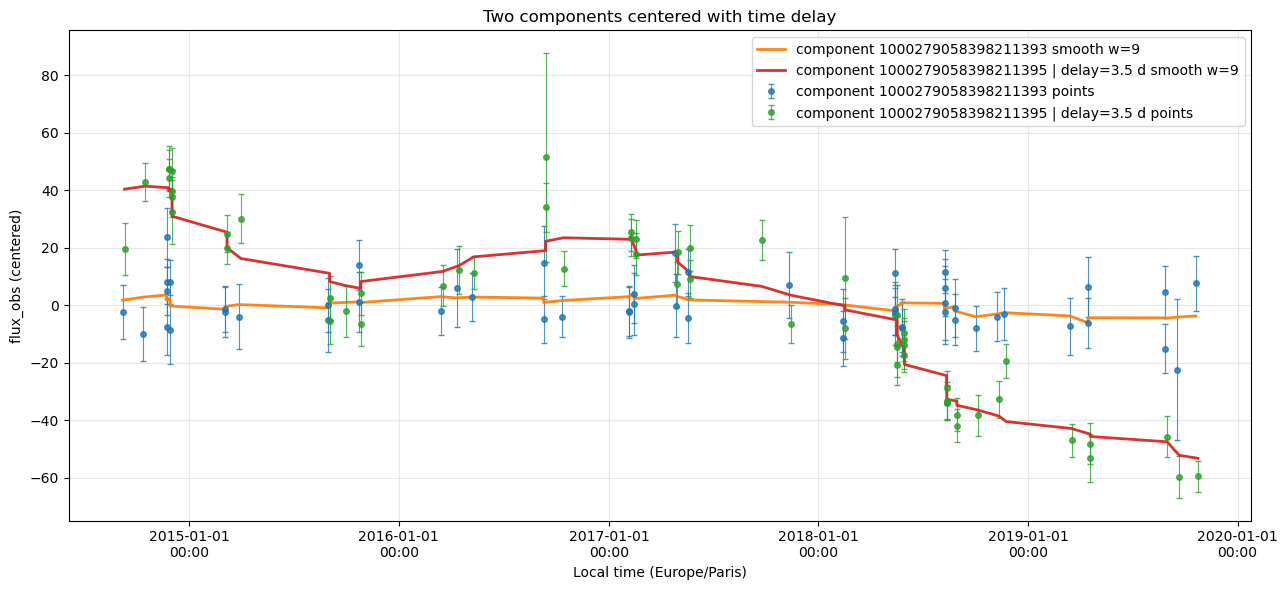

In [107]:
id1 = components[0]
id2 = components[1]

fig, ax = Plot.plot_lens_components_matplotlib(
    data_path,
    lens_component_ids=[id1, id2],
    y_col="flux_obs",
    yerr_col="flux_obs_error",

    y_mode="centered",

    show_points=True,
    show_smooth=True,
    show_gp=False,

    smooth_window=9,

    time_delay_by_component={
        str(id1): 0.0,
        str(id2): 3.5,   # delay in days
    },

    figsize=(13, 6),
    title="Two components centered with time delay",
)

plt.show()

# Plot avec Gaussian Process

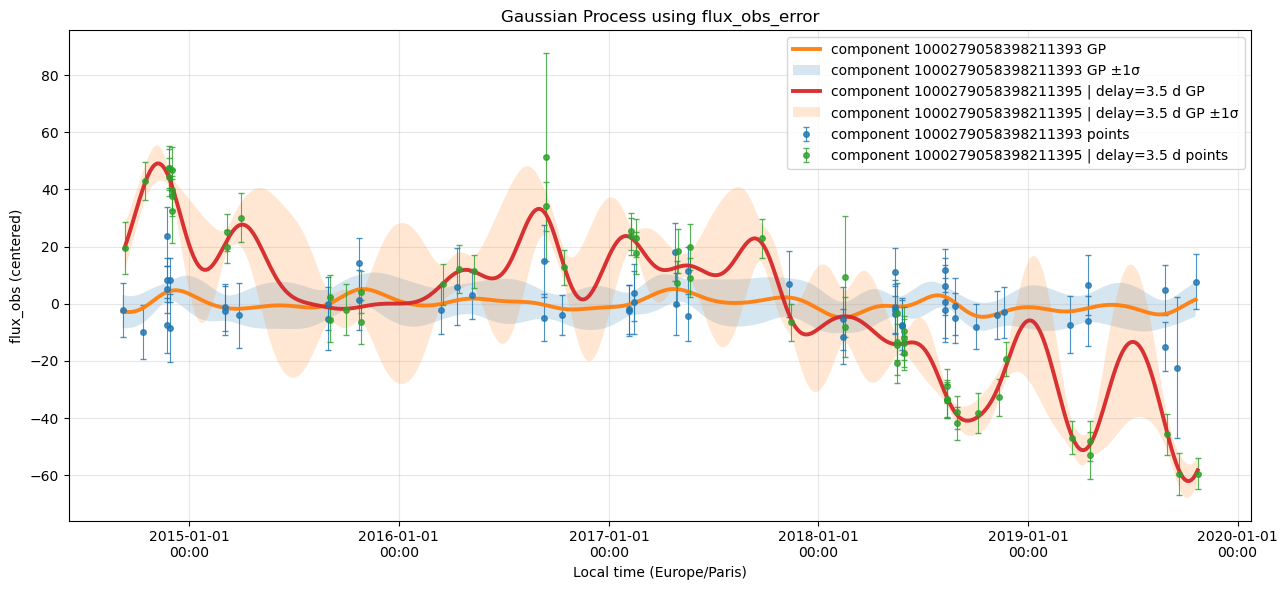

In [108]:
fig, ax = Plot.plot_lens_components_gp(
    data_path,
    lens_component_ids=[id1, id2],

    y_col="flux_obs",
    yerr_col="flux_obs_error",
    y_mode="centered",

    time_delay_by_component={
        str(id1): 0.0,
        str(id2): 3.5,
    },

    gp_length_scale_days=40.0,
    gp_error_scale=1,
    gp_show_uncertainty=True,
    gp_fixed_kernel=True,

    figsize=(13, 6),
    title="Gaussian Process using flux_obs_error",
)

plt.show()

In [ ]:
# If Pretraitement.py is in the same folder as the notebook:
from Utility import Pretraitement
# Or, if it is inside your package:
# from your_package.Pretraitement import preprocess_lightcurves, save_preprocessing_outputs


# Example input
# df = pd.read_csv("your_lightcurves.csv")
# or use your existing DataFrame directly.

clean_df, source_report, removed_points_df = Pretraitement.preprocess_lightcurves(
    df,

    # Columns, same style as your Plot.py
    time_col=None,                    # None = automatic guess
    y_col="flux_obs",
    yerr_col="flux_obs_error",
    source_col="source_id",
    component_col="lensComponentSourceId",

    # 1. Aggregate every 2 days
    do_bi_daily=True,
    bin_days=2.0,
    error_mode="mean",                # mean error every 2 days

    # 2. Fit one polynomial and EM with two polynomials
    poly_degree=3,
    em_max_iter=100,
    em_tol=1e-5,
    em_n_init=5,

    # 3. Remove whole source/component if 2-polynomial EM improves too much
    em_improvement_threshold=0.35,    # 35% improvement
    em_ratio_threshold=1.50,          # one-poly error / two-poly error

    # 4. If not removed by EM, remove 3 sigma points
    sigma_clip=3.0,

    # 5. Remove source/component with less than 20 points after preprocessing
    min_points_after=20,

    # Show every removed source and why
    show_removed_plots=True,
    verbose=True,
)

display(source_report)
display(removed_points_df)
display(clean_df)